## Load

In [19]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import FEATURES_CSV
df = pd.read_csv(FEATURES_CSV)
df["has_alphafold"] = df["plddt_mean"].notna().astype(int)
df["plddt_mean"] = df["plddt_mean"].fillna(0)
df["radius_of_gyration"] = df["radius_of_gyration"].fillna(df["radius_of_gyration"].median())
df.head()

,pdb_id,protein,variant,morphology,n_protofilaments,label,source,notes,length,frac_hydrophobic,...,plddt_median,frac_disordered,ss_helix,ss_sheet,ss_coil,sasa_total,sasa_hydrophobic,sasa_polar,sasa_hydrophobic_frac,has_alphafold
0,7Q4B,Amyloid-beta,Abeta42,single,1,0,Brain-derived,Type I brain-derived fold,42,0.476190,...,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377,0
1,2NAO,Amyloid-beta,Abeta42,multi,2,1,In vitro NMR,Double-horseshoe doublet,42,0.476190,...,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377,0
2,6W06,Amyloid-beta,Abeta40,single,1,0,In vitro,Single protofilament,293,0.412969,...,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377,0
3,2M4J,Amyloid-beta,Abeta40,multi,3,1,In vitro NMR,3-fold symmetric triplet,40,0.450000,...,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377,0
4,8RRR,Alpha-synuclein,WT,single,1,0,Brain-derived,Lewy fold,140,0.385714,...,NaN,0.0,0.650000,0.000000,0.350000,14827.285542,5715.487502,9111.798040,0.385471,0


## Sanity check feature distributions by class

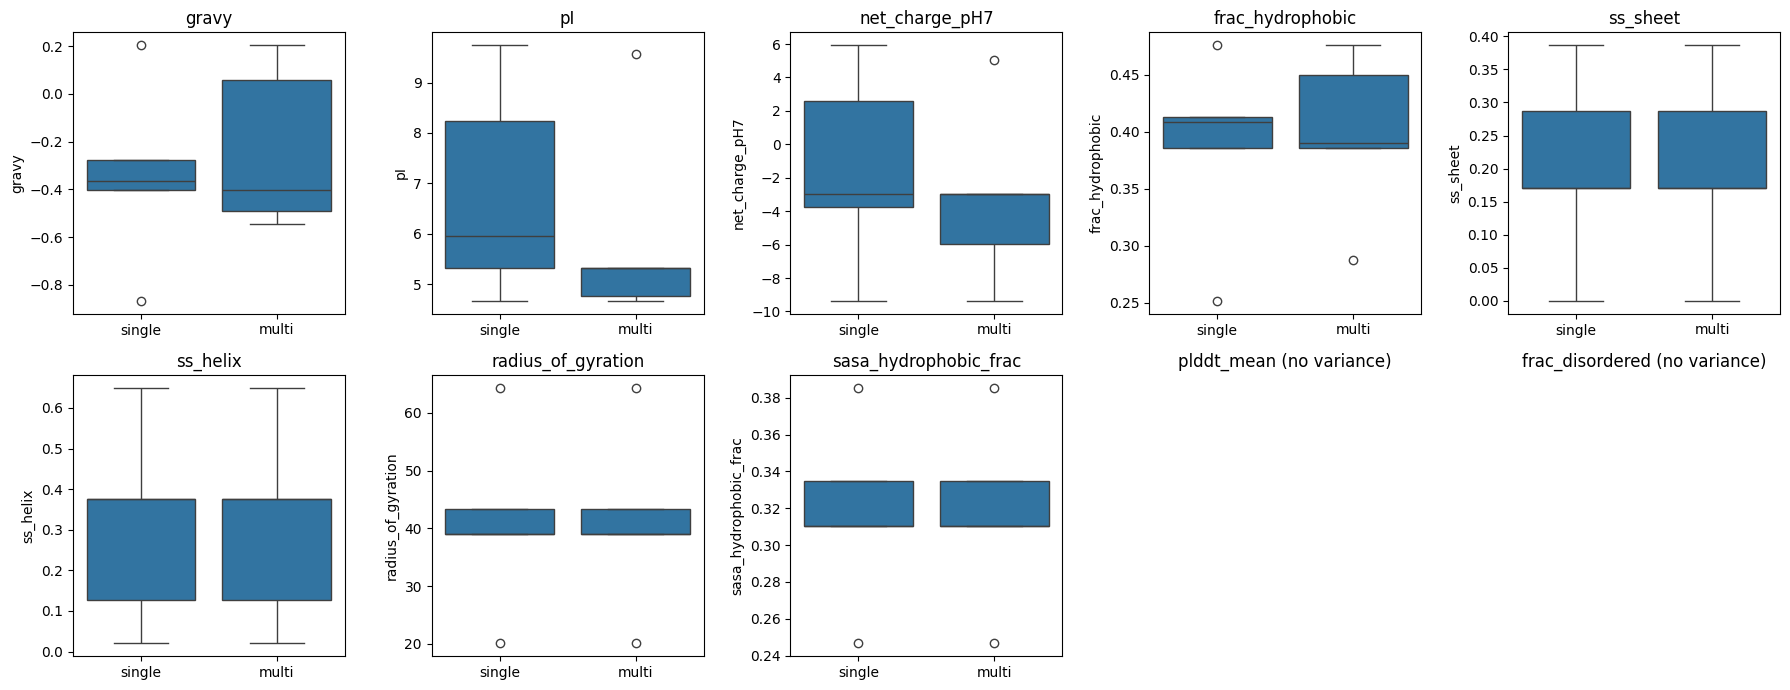

In [20]:
feature_cols = ["gravy","pI","net_charge_pH7","frac_hydrophobic",
                "ss_sheet","ss_helix","radius_of_gyration",
                "sasa_hydrophobic_frac","plddt_mean","frac_disordered"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, feature_cols):
    if col not in df.columns:
        ax.set_title(f"{col} (missing)")
        ax.axis("off")
        continue

    tmp = df[["morphology", col]].dropna()

    if tmp[col].nunique() < 2:
        ax.set_title(f"{col} (no variance)")
        ax.axis("off")
        continue

    sns.boxplot(data=tmp, x="morphology", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout(); plt.savefig("../results/feature_distributions.png", dpi=150)

## Correlation heatmap

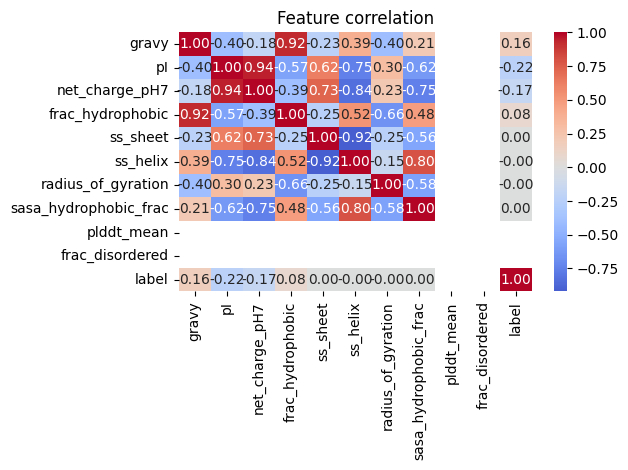

In [21]:
import numpy as np
num = df[feature_cols + ["label"]].copy()

num = num.apply(pd.to_numeric, errors="coerce")

num = num.fillna(num.median(numeric_only=True))
corr = num.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature correlation")
plt.tight_layout()
plt.savefig("../results/feature_correlation.png", dpi=150)